# Step 1

Get parameters for desired qubit parameters

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from datasets import get_dataset_config_names
from datasets import load_dataset

configs = get_dataset_config_names("SQuADDS/SQuADDS_DB")

components = []
component_names = []
data_types = []

for config in configs:
    try:
        components.append(config.split("-")[0])
        component_names.append(config.split("-")[1])
        data_types.append(config.split("-")[2])
    except:
        pass
    
print(components)
print(component_names)
print(data_types)

['qubit', 'cavity_claw', 'coupler', 'coupler', 'measured_device_database']
['TransmonCross', 'RouteMeander', 'NCap', 'CapNInterdigitalTee']
['cap_matrix', 'eigenmode', 'cap_matrix', 'cap_matrix']


In [3]:
from squadds import SQuADDS_DB

db = SQuADDS_DB()
db.get_configs()

['qubit-TransmonCross-cap_matrix',
 'cavity_claw-RouteMeander-eigenmode',
 'coupler-NCap-cap_matrix',
 'coupler-CapNInterdigitalTee-cap_matrix']


In [4]:
db.select_system(["qubit","cavity_claw"])
db.select_qubit("TransmonCross")
db.select_cavity_claw("RouteMeander")
db.select_resonator_type("quarter")
db.show_selections()

Selected qubit:  TransmonCross
Selected cavity:  RouteMeander
Selected coupler to feedline:  CLT
Selected resonator type:  quarter
Selected system:  ['qubit', 'cavity_claw']


In [5]:
merged_df = db.create_system_df()

In [6]:
from squadds import Analyzer

In [7]:
analyzer = Analyzer(db)

sanity check

In [8]:
db.selected_system

['qubit', 'cavity_claw']

In [9]:
analyzer.selected_system

['qubit', 'cavity_claw']

In [10]:
target_params = {
                "qubit_frequency_GHz": 4,
                "cavity_frequency_GHz": 7.4,
                "kappa_kHz": 120,
                "resonator_type":"quarter",
                "anharmonicity_MHz": -200,
                "g_MHz": 70}

In [11]:
results = analyzer.find_closest(target_params=target_params,
                                       num_top=1,
                                       metric="Euclidean",
                                       display=True)


Time taken to add the coupled H params: 5.983478784561157 seconds


In [12]:
for i in range(25,35):
    print(i,':',results.values[0][i])

25 : CLT
26 : {'claw_opts': {'connection_pads': {'readout': {'claw_cpw_length': '0um', 'claw_cpw_width': '11.7um', 'claw_gap': '5.1um', 'claw_length': '180um', 'claw_width': '15um', 'connector_location': '90', 'connector_type': '0', 'ground_spacing': '4.1um'}}, 'cross_gap': '0um', 'cross_length': '0um', 'cross_width': '0um', 'orientation': '-90', 'pos_x': '-1500um'}, 'cplr_opts': {'cap_distance': None, 'cap_gap': None, 'cap_gap_ground': None, 'cap_width': None, 'coupling_length': '230um', 'coupling_space': '7.9um', 'down_length': '50um', 'finger_count': None, 'finger_length': None, 'open_termination': False, 'orientation': '-90', 'prime_gap': '5.1um', 'prime_width': '11.7um', 'second_gap': '5.1um', 'second_width': '11.7um'}, 'cpw_opts': {'fillet': '49.9um', 'lead': {'end_straight': None, 'start_jogged_extension': None, 'start_straight': '50um'}, 'meander': {'asymmetry': '-115.0um', 'spacing': '100um'}, 'pin_inputs': {'end_pin': {'component': 'claw', 'pin': 'readout'}, 'start_pin': {'co

transmon information

In [13]:
results.values[0][6]

{'aedt_hfss_capacitance': 0,
 'aedt_hfss_inductance': 9.686e-09,
 'aedt_q3d_capacitance': 0,
 'aedt_q3d_inductance': 1e-08,
 'chip': 'main',
 'connection_pads': {'readout': {'claw_cpw_length': '40um',
   'claw_cpw_width': '10um',
   'claw_gap': '5.1um',
   'claw_length': '180um',
   'claw_width': '15um',
   'connector_location': '90',
   'connector_type': '0',
   'ground_spacing': '9.1um'}},
 'cross_gap': '30um',
 'cross_length': '200um',
 'cross_width': '30um',
 'gds_cell_name': 'my_other_junction',
 'hfss_capacitance': 0,
 'hfss_inductance': 9.686e-09,
 'hfss_mesh_kw_jj': 7e-06,
 'hfss_resistance': 0,
 'layer': '1',
 'orientation': '-90',
 'pos_x': '-1500um',
 'pos_y': '1200um',
 'q3d_capacitance': 0,
 'q3d_inductance': '10nH',
 'q3d_mesh_kw_jj': 7e-06,
 'q3d_resistance': 0}

resonator info

In [14]:
results.values[0][26]

{'claw_opts': {'connection_pads': {'readout': {'claw_cpw_length': '0um',
    'claw_cpw_width': '11.7um',
    'claw_gap': '5.1um',
    'claw_length': '180um',
    'claw_width': '15um',
    'connector_location': '90',
    'connector_type': '0',
    'ground_spacing': '4.1um'}},
  'cross_gap': '0um',
  'cross_length': '0um',
  'cross_width': '0um',
  'orientation': '-90',
  'pos_x': '-1500um'},
 'cplr_opts': {'cap_distance': None,
  'cap_gap': None,
  'cap_gap_ground': None,
  'cap_width': None,
  'coupling_length': '230um',
  'coupling_space': '7.9um',
  'down_length': '50um',
  'finger_count': None,
  'finger_length': None,
  'open_termination': False,
  'orientation': '-90',
  'prime_gap': '5.1um',
  'prime_width': '11.7um',
  'second_gap': '5.1um',
  'second_width': '11.7um'},
 'cpw_opts': {'fillet': '49.9um',
  'lead': {'end_straight': None,
   'start_jogged_extension': None,
   'start_straight': '50um'},
  'meander': {'asymmetry': '-115.0um', 'spacing': '100um'},
  'pin_inputs': {'en

In [15]:
%matplotlib inline

In [16]:
from squadds.interpolations.physics import ScalingInterpolator

In [17]:
interpolator = ScalingInterpolator(analyzer, target_params)

design_df = interpolator.get_design()

Kappa scaling: 0.9637788277521582
g scaling: 1.0033220365886828
alpha scaling: 1.0111571314159828
resonator scaling: 0.9005645809716217


In [18]:
design_df.values[0][1]

{'aedt_hfss_capacitance': 0,
 'aedt_hfss_inductance': 1.331327894626918e-08,
 'aedt_q3d_capacitance': 0,
 'aedt_q3d_inductance': 1.331327894626918e-08,
 'chip': 'main',
 'connection_pads': {'readout': {'claw_cpw_length': '0um',
   'claw_cpw_width': '10um',
   'claw_gap': '5.1um',
   'claw_length': '152.17743486051813um',
   'claw_width': '15um',
   'connector_location': '90',
   'connector_type': '0',
   'ground_spacing': '4.1um',
   'Lj': '13.31327894626918nH'}},
 'cross_gap': '30um',
 'cross_length': '212.3429975973564um',
 'cross_width': '30um',
 'gds_cell_name': 'my_other_junction',
 'hfss_capacitance': 0,
 'hfss_inductance': 1.331327894626918e-08,
 'hfss_mesh_kw_jj': 7e-06,
 'hfss_resistance': 0,
 'layer': '1',
 'orientation': '-90',
 'pos_x': '-1500um',
 'pos_y': '1200um',
 'q3d_capacitance': 0,
 'q3d_inductance': 1.331327894626918e-08,
 'q3d_mesh_kw_jj': 7e-06,
 'q3d_resistance': 0}

In [19]:
design_df.iloc[0]["design_options"]

{'cavity_claw_options': {'coupler_type': 'CLT',
  'coupler_options': {'cap_distance': None,
   'cap_gap': None,
   'cap_gap_ground': None,
   'cap_width': None,
   'coupling_length': '222um',
   'coupling_space': '7.9um',
   'down_length': '50um',
   'finger_count': None,
   'finger_length': None,
   'open_termination': False,
   'orientation': '-90',
   'prime_gap': '5.1um',
   'prime_width': '11.7um',
   'second_gap': '5.1um',
   'second_width': '11.7um'},
  'cpw_opts': {'left_options': {'fillet': '49.9um',
    'lead': {'end_straight': None,
     'start_jogged_extension': None,
     'start_straight': '50um'},
    'meander': {'asymmetry': '-115.0um', 'spacing': '100um'},
    'pin_inputs': {'end_pin': {'component': 'claw', 'pin': 'readout'},
     'start_pin': {'component': 'cplr', 'pin': 'second_end'}},
    'total_length': '3512um',
    'trace_gap': '5.1um',
    'trace_width': '11.7um'}}},
 'qubit_options': {'aedt_hfss_capacitance': 0,
  'aedt_hfss_inductance': 1.331327894626918e-08,
 

# Step 2
put parameters into qiskit-metal

In [20]:
import qiskit_metal as metal
from qiskit_metal import designs, draw
from qiskit_metal import MetalGUI, Dict, open_docs

%metal_heading Genshin Impact!

In [21]:
from qiskit_metal.qlibrary.qubits.transmon_pocket_6 import TransmonPocket6
from qiskit_metal.qlibrary.qubits.transmon_cross import TransmonCross
from qiskit_metal.qlibrary.qubits.transmon_cross_fl import TransmonCrossFL

from qiskit_metal.qlibrary.couplers.tunable_coupler_01 import TunableCoupler01

from qiskit_metal.qlibrary.tlines.meandered import RouteMeander
from qiskit_metal.qlibrary.tlines.pathfinder import RoutePathfinder
from qiskit_metal.qlibrary.tlines.anchored_path import RouteAnchors
from qiskit_metal.qlibrary.tlines.straight_path import RouteStraight

from qiskit_metal.qlibrary.lumped.cap_n_interdigital import CapNInterdigital
from qiskit_metal.qlibrary.couplers.cap_n_interdigital_tee import CapNInterdigitalTee
from qiskit_metal.qlibrary.couplers.coupled_line_tee import CoupledLineTee

from qiskit_metal.qlibrary.terminations.launchpad_wb import LaunchpadWirebond
from qiskit_metal.qlibrary.terminations.launchpad_wb_coupled import LaunchpadWirebondCoupled
from qiskit_metal.qlibrary.terminations.launchpad_wb_driven import LaunchpadWirebondDriven
from qiskit_metal.qlibrary.terminations.open_to_ground import OpenToGround
from qiskit_metal.qlibrary.terminations.short_to_ground import ShortToGround

from qiskit_metal.qlibrary.qubits.JJ_Manhattan import jj_manhattan

In [ ]:
design = metal.designs.DesignPlanar()
gui = metal.MetalGUI(design)


In [ ]:
design.overwrite_enabled = True
design.chips.main


In [ ]:
design._chips['main']['size']['size_x'] = '5mm'
design._chips['main']['size']['size_y'] = '5mm'
design._chips['main']['size']['center_x'] = '2.5mm'
design._chips['main']['size']['center_y'] = '2.5mm'
design.variables['cpw_width'] = '10 um'
design.variables['cpw_gap'] = '6 um'

In [23]:
qubit_1_options = design_df.iloc[0]["design_options"]["qubit_options"]
qubit_1_options.update(
    pos_x = '1.0mm',
    pos_y = '4.0mm',
)
qubit_1 = TransmonCross(design, 'Qubit_1', options=qubit_1_options)

gui.rebuild()
gui.autoscale()
gui.zoom_on_components(['Qubit_1'])

# Residual

There might be "kinks" in the CPW, which is a known issue in `qiskit-metal`.
To resolve this, try adjusting the `start_straight` or `end_straight` parameters.
For more details and resolution tips, check out this guide:
https://qiskit-community.github.io/qiskit-metal/tut/2-From-components-to-chip/2.12-Simple-Meander.html
There might be "kinks" in the CPW, which is a known issue in `qiskit-metal`.
To resolve this, try adjusting the `start_straight` or `end_straight` parameters.
For more details and resolution tips, check out this guide:
https://qiskit-community.github.io/qiskit-metal/tut/2-From-components-to-chip/2.12-Simple-Meander.html


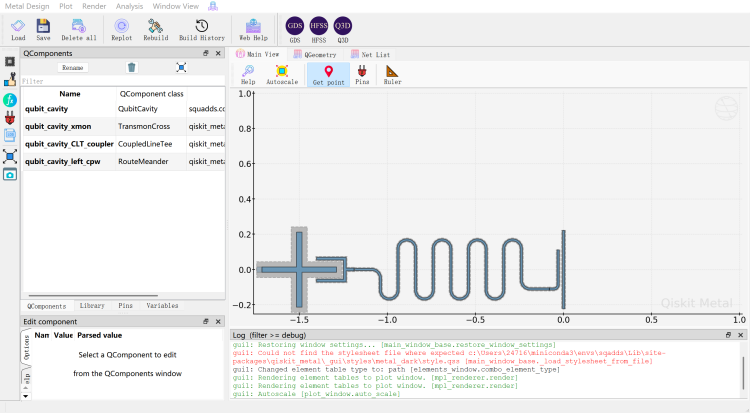

In [ ]:
from squadds.components.coupled_systems import QubitCavity
import qiskit_metal as metal
from qiskit_metal import Dict, MetalGUI, designs, draw
from qiskit_metal.toolbox_metal import math_and_overrides

design = metal.designs.design_planar.DesignPlanar()
gui = metal.MetalGUI(design)
design.overwrite_enabled = True
qc_ncap = QubitCavity(design, "qubit_cavity", options=design_df.iloc[0]["design_options"])
gui.rebuild()
gui.autoscale()
gui.screenshot("qubit_quarter_wave_cavity")

There might be "kinks" in the CPW, which is a known issue in `qiskit-metal`.
To resolve this, try adjusting the `start_straight` or `end_straight` parameters.
For more details and resolution tips, check out this guide:
https://qiskit-community.github.io/qiskit-metal/tut/2-From-components-to-chip/2.12-Simple-Meander.html


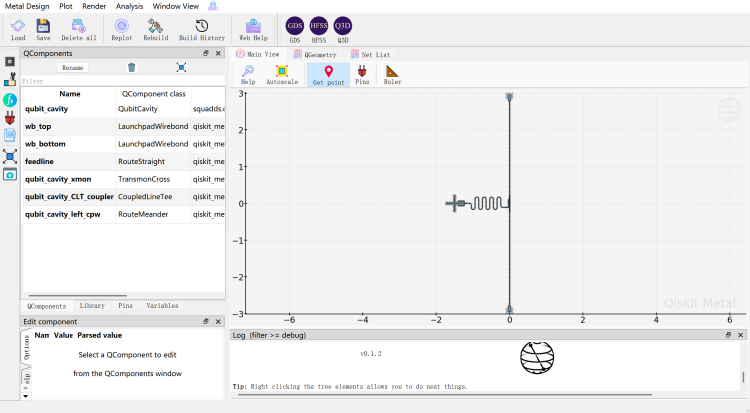

: 

In [ ]:
# qc_ncap.show(gui, include_wirebond_pads=True)

In [25]:
qc_ncap.to_gds("qubit_cavity", include_wirebond_pads=False)

04:20PM 51s WARNING [_import_junction_gds_file]: Not able to find file:"../resources/Fake_Junctions.GDS".  Not used to replace junction. Checked directory:"c:\Users\91566\Desktop\rz\Qubit_Design\qubit_design\resources".
